# Mass Spring Damper System: A PyTorch Implementation

This notebook presents a PyTorch implementation of the mass–spring–damper system.

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from pathlib import Path
from tqdm import tqdm
import pandas as pd
import matplotlib.pyplot as plt

# FIR Filter and System Model Definition

This section defines the system architecture.  
First, a learnable **FIR** filter is implemented in PyTorch to model linear temporal dynamics.  
Then, the mass–spring–damper system is constructed by combining two **FIR** modules that separately capture the free response and the force response of the system.

In [2]:
class FIR(nn.Module):
    def __init__(self, window_size, init_negexp=False):
        super().__init__()
        self.window_size = window_size
        self.weight = nn.Parameter(torch.zeros(1, 1, window_size))

        if init_negexp:
            t = torch.arange(window_size).float()
            w = torch.exp(-3 * t)
            w = 0.1 * w / w.sum()
            self.weight.data[:] = w.flip(0)
        else:
            self.weight.data.uniform_(0.0, 1.0)

    def forward(self, x):
        # x: (B, T)
        y = F.conv1d(x.unsqueeze(1), self.weight)
        return y.squeeze(1)

In [3]:
class NeuralMSD(nn.Module):
    def __init__(self, window_dim):
        super().__init__()
        self.window_dim = window_dim
        self.x_free = FIR(window_dim, init_negexp=True)
        self.x_force = FIR(window_dim)

    def step(self, x, u):
        return self.x_free(x) + self.x_force(u)

    def forward(self, x, u):
        return self.step(x, u)

    def rollout(self, x, u_seq, horizon):
        preds = []

        for k in range(horizon):
            u_k = u_seq[:, k : k + self.window_dim]

            x_next = self.step(x, u_k)  # (B,1)

            preds.append(x_next.squeeze(1))

            # shift window
            x = torch.cat([x[:, 1:], x_next], dim=1)

        return torch.stack(preds, dim=1)  # (B,H)

# Dataset and DataLoader

In PyTorch, the dataset must be defined explicitly. In this case, it is designed to handle sliding input windows, future prediction horizons, and to prevent sequences from crossing file boundaries.

In [ ]:
def load_simulation_file(path):
    data = np.loadtxt(path, delimiter=";")

    time = data[:, 0]
    x = data[:, 1]
    v = data[:, 2]
    u = data[:, 3]

    return x, v, u


from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from torch.utils.data import random_split


class MSDSimDataset(Dataset):
    def __init__(self, folder, window_dim, horizon=1, stride=1):
        self.window_dim = window_dim
        self.data = []  # file list
        self.index_map = []  # global window map
        self.horizon = horizon
        self.stride = stride

        files = sorted(Path(folder).glob("*.txt"))

        # load all files
        for f in files:
            x, v, u = load_simulation_file(f)

            x = torch.tensor(x, dtype=torch.float32)
            v = torch.tensor(v, dtype=torch.float32)
            u = torch.tensor(u, dtype=torch.float32)

            self.data.append((x, v, u))

        # build sliding window map
        for file_id, (x, _, _) in enumerate(self.data):
            T = len(x)
            max_start = T - self.window_dim - self.horizon

            for start in range(0, max_start, self.stride):
                self.index_map.append((file_id, start))

    def __len__(self):
        return len(self.index_map)

    def __getitem__(self, idx):
        file_id, start = self.index_map[idx]
        x, v, u = self.data[file_id]

        W = self.window_dim
        H = self.horizon

        return (
            x[start : start + W],
            x[start + W : start + W + H],
            u[start : start + W + H - 1],
        )


WINDOW_DIM = 10
HORIZON = 1

dataset = MSDSimDataset("../msd-data/data", window_dim=WINDOW_DIM, horizon=HORIZON)
n = len(dataset)
n_train = int(0.7 * n)
n_val = int(0.2 * n)
n_test = n - n_train - n_val

train_ds, val_ds, test_ds = random_split(dataset, [n_train, n_val, n_test])

train_loader = DataLoader(train_ds, batch_size=128, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=128, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=128, shuffle=False)

# Training Loop

This section defines the training and validation workflow. The model is optimized using Adam with MSE loss, and the best weights are saved according to the validation performance.

In [6]:
model = NeuralMSD(window_dim=WINDOW_DIM)
opt = torch.optim.Adam(model.parameters(), lr=5e-4)
loss_fn = nn.MSELoss()

best_val_loss = float("inf")

train_losses = []
val_losses = []

pbar = tqdm(range(80))
for epoch in pbar:
    model.train()
    total_loss = 0

    for x, x_next, u in train_loader:
        pred = model.step(x, u)
        loss = loss_fn(pred, x_next)

        opt.zero_grad()
        loss.backward()
        opt.step()

        total_loss += loss.item()
    train_losses.append(total_loss / len(train_loader))

    model.eval()
    val_loss = 0

    with torch.no_grad():
        for x, x_next, u in val_loader:
            pred = model.step(x, u)
            loss = loss_fn(pred, x_next)
            val_loss += loss.item()

    val_loss /= len(val_loader)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "saved/best_model.pth")
    val_losses.append(val_loss)
    pbar.set_description(
        f"Epoch {epoch + 1} | train loss: {total_loss / len(train_loader):.3e} | val_loss: {val_loss:.3e} | best_val_loss: {best_val_loss:.3e}"
    )

Epoch 80 | train loss: 1.043e-07 | val_loss: 6.713e-10 | best_val_loss: 1.629e-11: 100%|██████████| 80/80 [08:28<00:00,  6.35s/it]


## Closed-Loop Evaluation

The model is rolled out autoregressively, using its predictions as inputs at each step, and the resulting trajectory is compared with the ground truth.

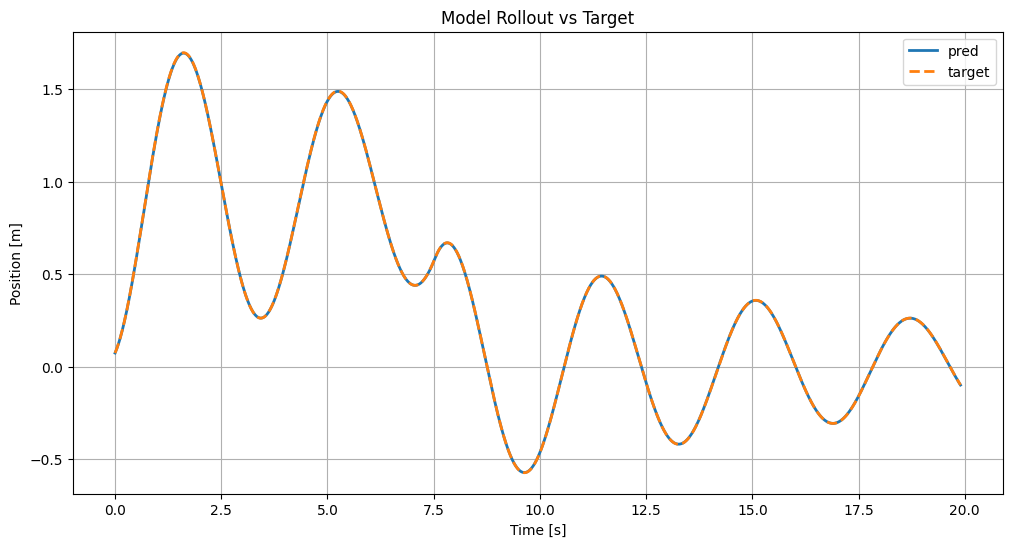

In [7]:
x, _, u = dataset.data[50]

best_model = NeuralMSD(window_dim=WINDOW_DIM)
best_model.load_state_dict(torch.load("saved/best_model.pth"))

preds = best_model.rollout(
    x[:WINDOW_DIM].unsqueeze(0), u.unsqueeze(0), horizon=len(x) - WINDOW_DIM
).squeeze(0)

target = x[WINDOW_DIM:]
t = np.arange(len(preds)) * 0.01
plt.figure(figsize=(12, 6))
plt.plot(t, preds.detach().numpy(), label="pred", linewidth=2)
plt.plot(t, target.numpy(), "--", label="target", linewidth=2)
plt.legend()
plt.grid()
plt.title("Model Rollout vs Target")
plt.xlabel("Time [s]")
plt.ylabel("Position [m]")
plt.show()

# Recurrent Training

In this stage, the model is trained in a recurrent fashion over a 15 s prediction horizon. A sequence-based dataset is built to generate input windows and multi-step targets, enabling rollout predictions over the entire horizon.  

During training, the model iteratively feeds its own predictions back as inputs, and the loss is computed over the full sequence.

In [ ]:
# Recurrent dataset
HORIZON = 1500

dataset = MSDSimDataset(
    "../msd-data/data", window_dim=WINDOW_DIM, horizon=HORIZON, stride=5
)
n = len(dataset)
n_train = int(0.7 * n)
n_val = int(0.2 * n)
n_test = n - n_train - n_val

train_ds, val_ds, test_ds = random_split(dataset, [n_train, n_val, n_test])

train_loader = DataLoader(train_ds, batch_size=128, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=128, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=128, shuffle=False)

In [11]:
# Recurrent train
model = best_model
opt = torch.optim.Adam(model.parameters(), lr=1e-5)
loss_fn = nn.MSELoss()

best_val_loss = float("inf")

train_losses = []
val_losses = []

pbar = tqdm(range(10))
for epoch in pbar:
    model.train()
    total_loss = 0

    for x, x_next, u_seq in train_loader:
        pred = model.rollout(x, u_seq, HORIZON)
        loss = loss_fn(pred, x_next)

        opt.zero_grad()
        loss.backward()
        opt.step()

        total_loss += loss.item()
    train_losses.append(total_loss / len(train_loader))

    model.eval()
    val_loss = 0

    with torch.no_grad():
        for x, x_next, u_seq in val_loader:
            pred = model.rollout(x, u_seq, HORIZON)
            loss = loss_fn(pred, x_next)
            val_loss += loss.item()

    val_loss /= len(val_loader)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "saved/best_model.pth")
    val_losses.append(val_loss)
    pbar.set_description(
        f"Epoch {epoch + 1} | train loss: {total_loss / len(train_loader):.3e} | val_loss: {val_loss:.3e} | best_val_loss: {best_val_loss:.3e}"
    )

Epoch 10 | train loss: 9.789e-07 | val_loss: 1.008e-06 | best_val_loss: 9.293e-07: 100%|██████████| 10/10 [08:37<00:00, 51.74s/it]


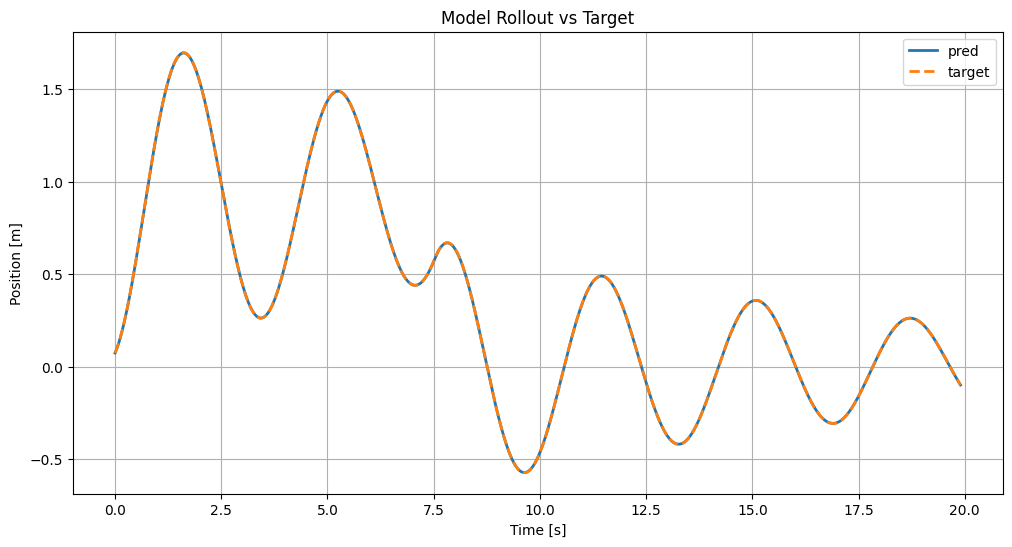

In [12]:
# Plot some predictions
x, _, u = dataset.data[50]

best_model = NeuralMSD(window_dim=WINDOW_DIM)
best_model.load_state_dict(torch.load("saved/best_model.pth"))

preds = best_model.rollout(
    x[:WINDOW_DIM].unsqueeze(0), u.unsqueeze(0), horizon=len(x) - WINDOW_DIM
).squeeze(0)

target = x[WINDOW_DIM:]
t = np.arange(len(preds)) * 0.01
plt.figure(figsize=(12, 6))
plt.plot(t, preds.detach().numpy(), label="pred", linewidth=2)
plt.plot(t, target.numpy(), "--", label="target", linewidth=2)
plt.legend()
plt.grid()
plt.title("Model Rollout vs Target")
plt.xlabel("Time [s]")
plt.ylabel("Position [m]")
plt.show()

# PID Controller and Closed-Loop Simulation

Here, a trainable **PID** controller is coupled with the plant model to simulate the system in closed loop. The control input is computed from the tracking error and applied recursively at each time step.

In [13]:
class PID(nn.Module):
    def __init__(self, dt):
        super().__init__()

        self.kp = nn.Parameter(torch.tensor(0.5))
        self.ki = nn.Parameter(torch.tensor(0.5))
        self.kd = nn.Parameter(torch.tensor(0.5))

        self.dt = dt

        # Internal state for integral and derivative (initialized in reset_state)
        self.register_buffer("integ_state", None, persistent=False)
        self.register_buffer("prev_error", None, persistent=False)

    def reset_state(self, batch_size, device=None):
        device = device or self.kp.device
        self.integ_state = torch.zeros((batch_size, 1), device=device)
        self.prev_error = torch.zeros((batch_size, 1), device=device)

    def forward(self, e):
        """
        e: (B,1)
        return: (B,1)
        """

        # Eular integration
        self.integ_state = self.integ_state + self.dt * e

        # Euler derivative
        deriv = (e - self.prev_error) / self.dt

        self.prev_error = e

        u = self.kp * e + self.ki * self.integ_state + self.kd * deriv

        return u

In [14]:
class ControlledSystem(nn.Module):
    def __init__(self, plant, pid):
        super().__init__()
        self.plant = plant
        self.pid = pid

    def forward(self, x0, target):
        x = x0
        u_seq = torch.zeros((x0.shape), device=x0.device)
        xs = []
        self.pid.reset_state(batch_size=x0.shape[0], device=x0.device)

        for k in range(target.shape[1]):
            e = target[:, k] - x[:, -1]
            # shift control sequence and append new control
            u_seq = torch.cat([u_seq[:, 1:], self.pid(e.unsqueeze(1))], dim=1)
            x_next = self.plant.step(x, u_seq)

            # shift state sequence and append new state
            x = torch.cat([x[:, 1:], x_next], dim=1)
            xs.append(x_next.squeeze(1))

        return torch.stack(xs, dim=1)

# PID Dataset and Controller Training

This section trains the **PID** controller in closed loop using rollout simulations. The plant dynamics are fixed, and only the **PID** gains are optimized to minimize the trajectory tracking error over the full horizon.

In [ ]:
# PID dataset
HORIZON = 500

dataset = MSDSimDataset(
    "../msd-data/data", window_dim=WINDOW_DIM, horizon=HORIZON, stride=5
)
n = len(dataset)
n_train = int(0.7 * n)
n_val = int(0.2 * n)
n_test = n - n_train - n_val

train_ds, val_ds, test_ds = random_split(dataset, [n_train, n_val, n_test])

train_loader = DataLoader(train_ds, batch_size=128, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=2048, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=2048, shuffle=False)

In [19]:
pid = PID(dt=0.01)
# Use the best model from the previous training as plant
system = ControlledSystem(best_model, pid)

# Only train the PID parameters, keep the plant fixed
opt = torch.optim.Adam(pid.parameters(), lr=0.05)
loss_fn = nn.MSELoss()

best_val_loss = float("inf")

train_losses = []
val_losses = []

pbar = tqdm(range(20))
for epoch in pbar:
    system.train()
    total_loss = 0

    for x, x_next, u in train_loader:
        pred = system(x, x_next)
        loss = loss_fn(pred, x_next)

        opt.zero_grad()
        loss.backward()
        opt.step()

        total_loss += loss.item()
    train_losses.append(total_loss / len(train_loader))

    system.eval()
    val_loss = 0

    with torch.no_grad():
        for x, x_next, u in val_loader:
            pred = system(x, x_next)
            loss = loss_fn(pred, x_next)
            val_loss += loss.item()

    val_loss /= len(val_loader)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(pid.state_dict(), "saved/best_controller.pth")
    val_losses.append(val_loss)
    pbar.set_description(
        f"Epoch {epoch + 1} | train loss: {total_loss / len(train_loader):.3e} | val_loss: {val_loss:.3e} | best_val_loss: {best_val_loss:.3e}"
    )

Epoch 20 | train loss: 3.254e-04 | val_loss: 3.056e-04 | best_val_loss: 3.056e-04: 100%|██████████| 20/20 [20:29<00:00, 61.49s/it]


In [20]:
# Print the parameter of the PID
print(
    f"Trained PID parameters: kp={pid.kp.item():.3f}, ki={pid.ki.item():.3f}, kd={pid.kd.item():.3f}"
)

Trained PID parameters: kp=16.196, ki=18.643, kd=8.131


## Controller Performance Evaluation

The learned PID controller is tested in closed loop on a reference trajectory and compared with the nnodely implementation to assess tracking performance.

In [21]:
best_pid = PID(dt=0.01)
best_pid.load_state_dict(torch.load("saved/best_controller.pth"))
best_system = ControlledSystem(best_model, best_pid)

tt = torch.linspace(0, 5, int(5 / 0.01))
data_target = torch.cat(
    [
        torch.ones(511, dtype=torch.float32) * 1.0,  # Step
        -2 * torch.ones(500, dtype=torch.float32) * 1.0,
        2 * torch.abs(2 * (tt * 1 / 5 - torch.floor(tt * 1 / 5 + 0.5))) - 1,  # Triangle
        2 * torch.abs(2 * (tt * 1 / 2.5 - torch.floor(tt * 1 / 2.5 + 0.5))) - 1,
    ]
)
best_system.eval()
preds = best_system(
    torch.zeros_like(data_target[1 : WINDOW_DIM + 1].unsqueeze(0)),
    data_target[WINDOW_DIM + 1 :].unsqueeze(0),
)

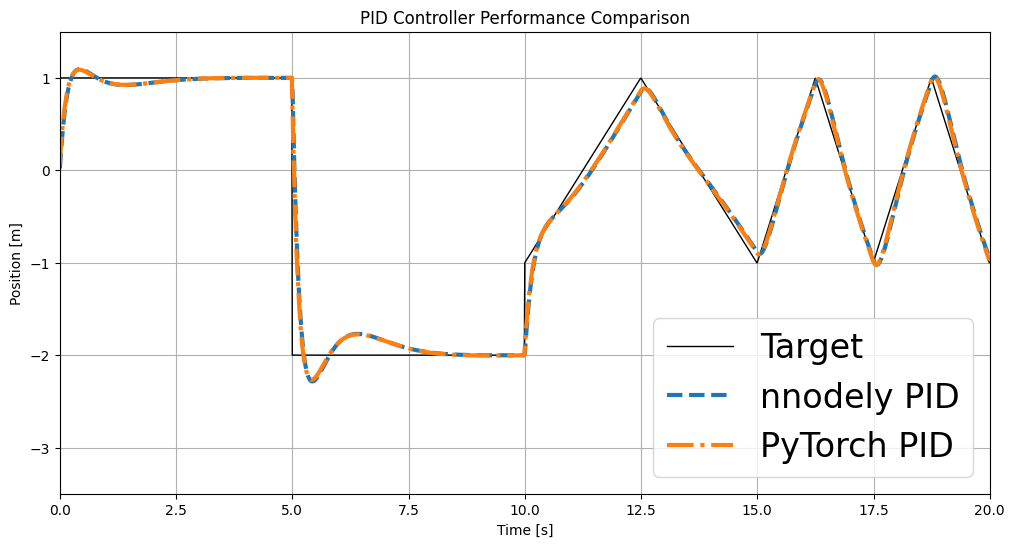

In [22]:
df = pd.read_csv("PID_test_nnodely.csv")

plt.figure(figsize=(12, 6))
t = torch.arange(len(preds.squeeze(0).detach().numpy())) * 0.01
plt.plot(
    t.numpy(),
    data_target[WINDOW_DIM + 1 :].numpy(),
    "-",
    label="Target",
    linewidth=1,
    color="black",
)
plt.plot(
    t.numpy(),
    df["estimate"].to_numpy(),
    "--",
    label="nnodely PID",
    linewidth=3,
    color="tab:blue",
)
plt.plot(
    t.numpy(),
    preds.squeeze(0).detach().numpy(),
    "-.",
    label="PyTorch PID",
    linewidth=3,
    color="tab:orange",
)
plt.xlim(0, 20)
plt.ylim(-3.5, 1.5)
plt.grid()
plt.title("PID Controller Performance Comparison")
plt.xlabel("Time [s]")
plt.ylabel("Position [m]")
plt.legend(loc="lower right", fontsize=24)
plt.show()